In [1]:
#import pandas
import pandas as pd 

In [12]:
#load the datasets

df = pd.read_csv("tested_1.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [13]:
#view first 10 rows

df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
5,897,0,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S
6,898,1,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q
7,899,0,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S
8,900,1,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C
9,901,0,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,NaN,S


In [14]:
#check how many rows and columns

df.shape

(418, 12)

In [15]:
# get column names

df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [16]:
# quick info about datatypes and missing values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [17]:
#check missing values clearly
df.isnull().sum()

# isnull() checks every set to know which part is missing and which part isn't, while .sum() counts the number of missing values and sums it up for us to see.

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [24]:
# handle missing values (Age)

# df["Age"] = df["Age"].fillna(df["Age"].median(), inplace = True) #this code is wrong

# Calculate the median first (just to be safe)
age_median = df["Age"].median()

# Fill the 86 missing values and save it back to the column
df["Age"] = df["Age"].fillna(age_median)


#in a case where you’ve done a lot of cleaning and don't want to reload the whole file, you can try to "restore" just that column from the original source

#original_df = pd.read_csv('your_file.csv')
#df['Age'] = original_df['Age']


In [26]:
#Quick Check
print(df["Age"].isnull().sum())

0


In [33]:
# handle fare

# Use the first value of the mode
df["Fare"] = df["Fare"].fillna(df["Fare"].mode()[0])

# Double check
print(df["Fare"].isnull().sum())

0


In [31]:
# handle cabin
df.drop (['Name', 'Ticket', 'Cabin'], axis=1, inplace = True)

In [34]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Sex          418 non-null    object 
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Fare         418 non-null    float64
 8   Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(2)
memory usage: 29.5+ KB


In [36]:
# Convert text to numbers
# Mapping is great for two options (Binary)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [37]:
# get_dummies is better for 3+ options (like Embarked ports)
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [38]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,892,0,3,0,34.5,0,0,7.8292,True,False
1,893,1,3,1,47.0,1,0,7.0000,False,True
2,894,0,2,0,62.0,0,0,9.6875,True,False
3,895,0,3,0,27.0,0,0,8.6625,False,True
4,896,1,3,1,22.0,1,1,12.2875,False,True


In [39]:
#Split into X (Features) and y (Target)
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [40]:
X

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,892,3,0,34.5,0,0,7.8292,True,False
1,893,3,1,47.0,1,0,7.0000,False,True
2,894,2,0,62.0,0,0,9.6875,True,False
3,895,3,0,27.0,0,0,8.6625,False,True
4,896,3,1,22.0,1,1,12.2875,False,True
...,...,...,...,...,...,...,...,...,...
413,1305,3,0,27.0,0,0,8.0500,False,True
414,1306,1,1,39.0,0,0,108.9000,False,False
415,1307,3,0,38.5,0,0,7.2500,False,True
416,1308,3,0,27.0,0,0,8.0500,False,True


In [41]:
y

0      0
1      1
2      0
3      0
4      1
      ..
413    0
414    1
415    0
416    0
417    0
Name: Survived, Length: 418, dtype: int64

In [42]:
#split into training and testing
from sklearn.model_selection import train_test_split

In [43]:
#Split into training and testing (80% to learn, 20% to test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a model

In [44]:
from sklearn.linear_model import LogisticRegression

In [45]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [46]:
#Evaluate
y_pred = model.predict(X_test)

In [47]:
#Evaluate results
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [48]:
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 1.0

Confusion Matrix:
[[50  0]
 [ 0 34]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



## Getting Data from API(mini practical)

In [49]:
import requests

In [50]:
api_url = "https://api.open-meteo.com/v1/forecast?latitude=6.52&longitude=3.37&hourly=temperature_2m"
response = requests.get(api_url)
data = response.json()

In [51]:
weather_df = pd.DataFrame({
    "time": data["hourly"] ["time"],
    "temperature": data["hourly"] ["temperature_2m"]
})
weather_df.head()

,time,temperature
0,2026-04-12T00:00,27.9
1,2026-04-12T01:00,27.8
2,2026-04-12T02:00,27.6
3,2026-04-12T03:00,27.6
4,2026-04-12T04:00,27.6


In [53]:
url = "https://jsonplaceholder.typicode.com/posts"
response = requests.get(url)

# Status code 200 means "Success!"
print(f"Status Code: {response.status_code}")

Status Code: 200


In [54]:
if response.status_code == 200:
    data = response.json()
    # Convert the list of dictionaries into a clean table
    posts_df = pd.DataFrame(data)
    print(posts_df.head())

   userId  id                                              title  \
0       1   1  sunt aut facere repellat provident occaecati e...   
1       1   2                                       qui est esse   
2       1   3  ea molestias quasi exercitationem repellat qui...   
3       1   4                               eum et est occaecati   
4       1   5                                 nesciunt quas odio   

                                                body  
0  quia et suscipit\nsuscipit recusandae consequu...  
1  est rerum tempore vitae\nsequi sint nihil repr...  
2  et iusto sed quo iure\nvoluptatem occaecati om...  
3  ullam et saepe reiciendis voluptatem adipisci\...  
4  repudiandae veniam quaerat sunt sed\nalias aut...  


## Getting data via webscrapping 

webscrapping means collecting data from a webpage's HTML.

In [55]:
import requests
from bs4 import BeautifulSoup

In [56]:
url = "http://quotes.toscrape.com/"
response = requests.get(url)

In [57]:
response.status_code

200

In [58]:
# soup is like a "translated" version of the website that Python can search
soup = BeautifulSoup(response.text, "html.parser")

In [59]:
# Find every block on the page that looks like a quote
quote_blocks = soup.find_all("div", class_="quote")

In [60]:
len(quote_blocks)

10

In [61]:
quotes_list = []

for block in quote_blocks:
    # Pull the text and author inside each block
    text = block.find("span", class_="text").get_text()
    author = block.find("small", class_="author").get_text()
    
    quotes_list.append({"quote": text, "author": author})

In [62]:
# Convert your list of quotes into a DataFrame for analysis
quotes_df = pd.DataFrame(quotes_list)
print(quotes_df.head())

                                               quote           author
0  “The world as we have created it is a process ...  Albert Einstein
1  “It is our choices, Harry, that show what we t...     J.K. Rowling
2  “There are only two ways to live your life. On...  Albert Einstein
3  “The person, be it gentleman or lady, who has ...      Jane Austen
4  “Imperfection is beauty, madness is genius and...   Marilyn Monroe


## Dealing with missing values, outliers and Data Normalization


#### Objectives

- load a dataset using pandas
- Identify missing values
- Handle missing data using imputation
- Detect outliers
- Treat outliers
- Normalize Data
- Visualize cleaned data


#### Structure

- Missing values
- Outliers
- Normalization

### Structured data (Tabular data)

**Data structure, Cleaning, Manipulation, Analysis**
- Numpy
- Pandas

**Visualization**
- Matplotlib
- Seaborne

**Machine Learning**
- Scikit_learn

In [69]:
import pandas as pd
import numpy as np

In [71]:
dir(pd)

['ArrowDtype',
 'BooleanDtype',
 'Categorical',
 'CategoricalDtype',
 'CategoricalIndex',
 'DataFrame',
 'DateOffset',
 'DatetimeIndex',
 'DatetimeTZDtype',
 'ExcelFile',
 'ExcelWriter',
 'Flags',
 'Float32Dtype',
 'Float64Dtype',
 'Grouper',
 'HDFStore',
 'Index',
 'IndexSlice',
 'Int16Dtype',
 'Int32Dtype',
 'Int64Dtype',
 'Int8Dtype',
 'Interval',
 'IntervalDtype',
 'IntervalIndex',
 'MultiIndex',
 'NA',
 'NaT',
 'NamedAgg',
 'Period',
 'PeriodDtype',
 'PeriodIndex',
 'RangeIndex',
 'Series',
 'SparseDtype',
 'StringDtype',
 'Timedelta',
 'TimedeltaIndex',
 'Timestamp',
 'UInt16Dtype',
 'UInt32Dtype',
 'UInt64Dtype',
 'UInt8Dtype',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__docformat__',
 '__file__',
 '__git_version__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 '_built_with_meson',
 '_config',
 '_is_numpy_dev',
 '_libs',
 '_pandas_datetime_CAPI',
 '_pandas_parser_CAPI',
 '_testing',
 '_typing',
 '_version_meson',
 'annota

In [78]:
# this will pass an empty dataframe, unless when assigned a value

df = pd.DataFrame()
df

""


In [91]:
student_dict = {
    "Name": ['Amina', 'Fatima', 'John', 'Rodney', 'Hollan'],
    "Age": [17, np.nan, 16, 20, 17],
    "Math_score": [85, 70, 69, 55, 72],
    "English_score": [65, 72, 89, 53, 91],
    "Monthly_allowance": [20000, 40000, 100000, 55000, np.nan]
}

df = pd.DataFrame(student_dict)
df

#np.nan tells python that you need a none value like an empty value in your data frame or table
# note that when you're running a dataframe your number of values must be the same

,Name,Age,Math_score,English_score,Monthly_allowance
0,Amina,17.0,85,65,20000.0
1,Fatima,NaN,70,72,40000.0
2,John,16.0,69,89,100000.0
3,Rodney,20.0,55,53,55000.0
4,Hollan,17.0,72,91,NaN


In [72]:
student_dict.keys()

dict_keys(['Name', 'Age', 'Math_score', 'English_score', 'Monthly_allowance'])

In [73]:
student_dict.values()

dict_values([['Amina', 'Fatima', 'John', 'Rodney', 'Hollan'], [17, nan, 16, 20, 17], [85, 70, 69, 55, 72], [65, 72, 89, 53, 91], [20000, 40000, 100000, 55000, nan]])

In [75]:
pd.DataFrame?
# this is to check the function's role
# or help(pd.DataFrame)

Init signature:
pd.DataFrame(
    data=None,
    index: 'Axes | None' = None,
    columns: 'Axes | None' = None,
    dtype: 'Dtype | None' = None,
    copy: 'bool | None' = None,
) -> 'None'
Docstring:     
Two-dimensional, size-mutable, potentially heterogeneous tabular data.

Data structure also contains labeled axes (rows and columns).
Arithmetic operations align on both row and column labels. Can be
thought of as a dict-like container for Series objects. The primary
pandas data structure.

Parameters
----------
data : ndarray (structured or homogeneous), Iterable, dict, or DataFrame
    Dict can contain Series, arrays, constants, dataclass or list-like objects. If
    data is a dict, column order follows insertion-order. If a dict contains Series
    which have an index defined, it is aligned by its index. This alignment also
    occurs if data is a Series or a DataFrame itself. Alignment is done on
    Series/DataFrame inputs.

    If data is a list of dicts, column order follows 

In [89]:
student_dict = {
    "Name": ['Ann'],
    "Age": [23],
    "Math_score": [92],
    "English_score": [89],
    "Monthly_allowance": [100000]
}

In [84]:
df = pd.DataFrame(student_dict, index=[0])
df

#this is a case where we are passing a little number of valuse so we tell it the number of rows and columns and it interprtes index 0 as 1 row and column

,Name,Age,Math_score,English_score,Monthly_allowance
0,Ann,23,92,89,100000


In [93]:
df.to_csv("students_test_data.csv")
print("Students data csv file created ✅")

Students data csv file created ✅


In [98]:
dir(pd.DataFrame)

# or dir(df)

['T',
 '_AXIS_LEN',
 '_AXIS_ORDERS',
 '_AXIS_TO_AXIS_NUMBER',
 '_HANDLED_TYPES',
 '__abs__',
 '__add__',
 '__and__',
 '__annotations__',
 '__array__',
 '__array_priority__',
 '__array_ufunc__',
 '__arrow_c_stream__',
 '__bool__',
 '__class__',
 '__contains__',
 '__copy__',
 '__dataframe__',
 '__dataframe_consortium_standard__',
 '__deepcopy__',
 '__delattr__',
 '__delitem__',
 '__dict__',
 '__dir__',
 '__divmod__',
 '__doc__',
 '__eq__',
 '__finalize__',
 '__firstlineno__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__iand__',
 '__ifloordiv__',
 '__imod__',
 '__imul__',
 '__init__',
 '__init_subclass__',
 '__invert__',
 '__ior__',
 '__ipow__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__ixor__',
 '__le__',
 '__len__',
 '__lt__',
 '__matmul__',
 '__mod__',
 '__module__',
 '__mul__',
 '__ne__',
 '__neg__',
 '__new__',
 '__nonzero__',
 '__or__',
 '__pandas_priority__',
 '__pos__

In [96]:
type(df)

pandas.core.frame.DataFrame

In [100]:
df = pd.read_csv("students_test_data.csv")
print("Here is the saved csv file")
print("You can read it here in your notebook throug pandas")

df

Here is the saved csv file
You can read it here in your notebook throug pandas


,Unnamed: 0,Name,Age,Math_score,English_score,Monthly_allowance
0,0,Amina,17.0,85,65,20000.0
1,1,Fatima,NaN,70,72,40000.0
2,2,John,16.0,69,89,100000.0
3,3,Rodney,20.0,55,53,55000.0
4,4,Hollan,17.0,72,91,NaN


In [101]:
# the reason we have an unamed column is because our index = True, meaning that it can assign the index numbering of the dataframe to a column of it's own

help(pd.DataFrame.to_csv)

Help on function to_csv in module pandas.core.generic:

to_csv(
    self,
    path_or_buf: 'FilePath | WriteBuffer[bytes] | WriteBuffer[str] | None' = None,
    *,
    sep: 'str' = ',',
    na_rep: 'str' = '',
    float_format: 'str | Callable | None' = None,
    columns: 'Sequence[Hashable] | None' = None,
    header: 'bool_t | list[str]' = True,
    index: 'bool_t' = True,
    index_label: 'IndexLabel | None' = None,
    mode: 'str' = 'w',
    encoding: 'str | None' = None,
    compression: 'CompressionOptions' = 'infer',
    quoting: 'int | None' = None,
    quotechar: 'str' = '"',
    lineterminator: 'str | None' = None,
    chunksize: 'int | None' = None,
    date_format: 'str | None' = None,
    doublequote: 'bool_t' = True,
    escapechar: 'str | None' = None,
    decimal: 'str' = '.',
    errors: 'OpenFileErrors' = 'strict',
    storage_options: 'StorageOptions | None' = None
) -> 'str | None'
    Write object to a comma-separated values (csv) file.

    Parameters
    --------

In [116]:
# lets handel that here but with new data

staffs_dict = {
    "Name": ['Ann', 'Collins', 'Fejiro', 'Adanna', 'Tejiri', 'Golden'],
    "Age": [23, 29, 26, 28, 22, 27],
    "Accuracy_score": [92, 81, 72, 88, 56, 83],
    "English_fluency": [89, 98, 72, 56, 61, 84],
    "Net_salary": [1000000, 400000, 250000, 500000, 350000, 420000]
}

df = pd.DataFrame(staffs_dict)

df

,Name,Age,Accuracy_score,English_fluency,Net_salary
0,Ann,23,92,89,1000000
1,Collins,29,81,98,400000
2,Fejiro,26,72,72,250000
3,Adanna,28,88,56,500000
4,Tejiri,22,56,61,350000
5,Golden,27,83,84,420000


In [117]:
#save to csv but without the index numbers

df.to_csv("staff_test_data.csv", index = False)
print("CSV file saved to folder as staff_test_data.csv, and it is saved without the index numbering")
print("You can read it here in your notebook through pandas")

df

CSV file saved to folder as staff_test_data.csv, and it is saved without the index numbering
You can read it here in your notebook through pandas


,Name,Age,Accuracy_score,English_fluency,Net_salary
0,Ann,23,92,89,1000000
1,Collins,29,81,98,400000
2,Fejiro,26,72,72,250000
3,Adanna,28,88,56,500000
4,Tejiri,22,56,61,350000
5,Golden,27,83,84,420000


In [114]:
#lets save to excel but without the index numbers

df.to_excel("staff_test_data.xlsx", index = False)
print("Excel file saved to folder as staff_test_data.xlsx, and it is saved without the index numbering")
print("You can read it here in your notebook through pandas")

df

Excel file saved to folder as staff_test_data.xlsx, and it is saved without the index numbering
You can read it here in your notebook through pandas


,Name,Age,Math_score,English_score,Monthly_allowance
0,Amina,17.0,85,65,20000.0
1,Fatima,NaN,70,72,40000.0
2,John,16.0,69,89,100000.0
3,Rodney,20.0,55,53,55000.0
4,Hollan,17.0,72,91,NaN


In [106]:
# In a case where our Excel file has multiple sheets and we want to read just one, this is the how we would write our code

# df = read_excel("staff_test_data.xlsx", sheetname = 'what ever that sheet is called')

# Also note that we can save our dataframe data to a particular sheet in excel with it's own sheet name and it just the same process as reading where we add the sheet name.

In [108]:
# we know how to view first and last few rows, but when we want to see some rows at random
df.sample() #this gives us different random rows at different intervals and we could also put in the number of random rows as df.sampl(2) or any number we want

,Name,Age,Accuracy_score,English_fluency,Net_salary
3,Adanna,28,88,56,500000


In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Name             6 non-null      object
 1   Age              6 non-null      int64 
 2   Accuracy_score   6 non-null      int64 
 3   English_fluency  6 non-null      int64 
 4   Net_salary       6 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 372.0+ bytes


### Check for missing Values

In [118]:
#df.isnull()
df.isna()

# either way they both tell us the number of missing valuse in your dataframe (note that in your .info() function it only tells you if there are missing values by showing you the numbe rof present values, non-null)

,Name,Age,Accuracy_score,English_fluency,Net_salary
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
5,False,False,False,False,False


In [163]:
#using this one that has some missing values
student_dict = {
    "Name": ['Amina', 'Fatima', 'John', 'Rodney', 'Hollan'],
    "Age": [17, np.nan, 16, 20, 17],
    "Math_score": [85, 70, 69, 55, 72],
    "English_score": [65, 72, 89, 53, 91],
    "Monthly_allowance": [20000, 40000, 100000, 55000, np.nan]
}

df = pd.DataFrame(student_dict)
df

,Name,Age,Math_score,English_score,Monthly_allowance
0,Amina,17.0,85,65,20000.0
1,Fatima,NaN,70,72,40000.0
2,John,16.0,69,89,100000.0
3,Rodney,20.0,55,53,55000.0
4,Hollan,17.0,72,91,NaN


In [120]:
df.isnull()

,Name,Age,Math_score,English_score,Monthly_allowance
0,False,False,False,False,False
1,False,True,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,True


In [121]:
# to see the sum of the missing values
df.isnull().sum() # it would do a column wise addition to sum up the missing values

# using python's sum function is sum(df.isnull())

Name                 0
Age                  1
Math_score           0
English_score        0
Monthly_allowance    1
dtype: int64

In [122]:
# but when we're doimg a row wise summation of the missing values the sum function will carry an axis = 1
df.isnull().sum(axis=1)

# note that axis = 0 is stilll for column wise summation

0    0
1    1
2    0
3    0
4    1
dtype: int64

In [123]:
# you can always use the help function to understand better

help(df.sum)

Help on method sum in module pandas.core.frame:

sum(
    axis: 'Axis | None' = 0,
    skipna: 'bool' = True,
    numeric_only: 'bool' = False,
    min_count: 'int' = 0,
    **kwargs
) method of pandas.core.frame.DataFrame instance
    Return the sum of the values over the requested axis.

    This is equivalent to the method ``numpy.sum``.

    Parameters
    ----------
    axis : {index (0), columns (1)}
        Axis for the function to be applied on.
        For `Series` this parameter is unused and defaults to 0.

        .. warning::

            The behavior of DataFrame.sum with ``axis=None`` is deprecated,
            in a future version this will reduce over both axes and return a scalar
            To retain the old behavior, pass axis=0 (or do not pass axis).

        .. versionadded:: 2.0.0

    skipna : bool, default True
        Exclude NA/null values when computing the result.
    numeric_only : bool, default False
        Include only float, int, boolean columns. Not im

In [125]:
df.select_dtypes(exclude = 'O') 
# this function is used to remove a particular data type from your data frame when you want to view it
# note that over here what we excluded was the string which pandas identify as an object 'O' and the object here is the name

,Age,Math_score,English_score,Monthly_allowance
0,17.0,85,65,20000.0
1,NaN,70,72,40000.0
2,16.0,69,89,100000.0
3,20.0,55,53,55000.0
4,17.0,72,91,NaN


In [126]:
#let's exclude the integers 

df.select_dtypes(exclude = 'int') 

#so we shouldn't expect to see the english and math score in the dataframe

,Name,Age,Monthly_allowance
0,Amina,17.0,20000.0
1,Fatima,NaN,40000.0
2,John,16.0,100000.0
3,Rodney,20.0,55000.0
4,Hollan,17.0,NaN


In [127]:
# important not, when we do any aggregate function like min, max, mean, median,sum etc. python pandas processes your axis = 0 in column and also as the default calculation and uses asix = 1 as row calculation
# But for everyother functions like fillna, drop etc, it takes the default processing and the axis = 0 for rows and axis = 1 for columns

### Handle Missing values

Drop missing rows

In [129]:
?df.dropna

#the drop function is to drop anything, while the dropna is to drop the nan/null/empty values

Signature:
df.dropna(
    *,
    axis: 'Axis' = 0,
    how: 'AnyAll | lib.NoDefault' = <no_default>,
    thresh: 'int | lib.NoDefault' = <no_default>,
    subset: 'IndexLabel | None' = None,
    inplace: 'bool' = False,
    ignore_index: 'bool' = False,
) -> 'DataFrame | None'
Docstring:
Remove missing values.

See the :ref:`User Guide <missing_data>` for more on which values are
considered missing, and how to work with missing data.

Parameters
----------
axis : {0 or 'index', 1 or 'columns'}, default 0
    Determine if rows or columns which contain missing values are
    removed.

    * 0, or 'index' : Drop rows which contain missing values.
    * 1, or 'columns' : Drop columns which contain missing value.

    Only a single axis is allowed.

how : {'any', 'all'}, default 'any'
    Determine if row or column is removed from DataFrame, when we have
    at least one NA or all NA.

    * 'any' : If any NA values are present, drop that row or column.
    * 'all' : If all values are NA, d

In [151]:
df.loc # this means location and it is used to access a data in a particular location in rows (works with both texts and numbers)
df.iloc # this means index location (works only for numbers)

In [137]:
df.loc[2] #this checks for the data in row 2

Name                     John
Age                      16.0
Math_score                 69
English_score              89
Monthly_allowance    100000.0
Name: 2, dtype: object

In [164]:
df.loc[[4, 3]] #this checks the for data of 2 different locations 4 and 3

,Name,Age,Math_score,English_score,Monthly_allowance
4,Hollan,17.0,72,91,NaN
3,Rodney,20.0,55,53,55000.0


In [170]:
# if we want to check for a particular row in that data 

df.loc[2, "Age"]

#WE WOULD SEE the age as 16 for John in row 2

np.float64(16.0)

In [171]:
# if we use iloc in this case it won't work because there is a text/str

# try it by removing the comment

#df.iloc[2, "Age"]

#instead you use the index number for iloc eg.

df.iloc[2, 1]

#this shows the data for row 2 and column 1, remember you're counting by 0, 1, 2 etc

np.float64(16.0)

In [172]:
# you can also use the loc and iloc function to update your dataframe.

# e.g let's update row 4 with monthly allowances of 20000 in place of it's original value, Nan

df.iloc[4]

Name                 Hollan
Age                    17.0
Math_score               72
English_score            91
Monthly_allowance       NaN
Name: 4, dtype: object

In [173]:
# remeber the monthly allowance is at row 4

df.iloc[4, 4] = 20000

In [174]:
df.loc[4]

Name                  Hollan
Age                     17.0
Math_score                72
English_score             91
Monthly_allowance    20000.0
Name: 4, dtype: object

In [175]:
help(df.dropna)

Help on method dropna in module pandas.core.frame:

dropna(
    *,
    axis: 'Axis' = 0,
    how: 'AnyAll | lib.NoDefault' = <no_default>,
    thresh: 'int | lib.NoDefault' = <no_default>,
    subset: 'IndexLabel | None' = None,
    inplace: 'bool' = False,
    ignore_index: 'bool' = False
) -> 'DataFrame | None' method of pandas.core.frame.DataFrame instance
    Remove missing values.

    See the :ref:`User Guide <missing_data>` for more on which values are
    considered missing, and how to work with missing data.

    Parameters
    ----------
    axis : {0 or 'index', 1 or 'columns'}, default 0
        Determine if rows or columns which contain missing values are
        removed.

        * 0, or 'index' : Drop rows which contain missing values.
        * 1, or 'columns' : Drop columns which contain missing value.

        Only a single axis is allowed.

    how : {'any', 'all'}, default 'any'
        Determine if row or column is removed from DataFrame, when we have
        at le

In [178]:
df.dropna(axis = 0, how = 'all') #this shows the df with all the nan values

,Name,Age,Math_score,English_score,Monthly_allowance
0,Amina,17.0,85,65,20000.0
1,Fatima,NaN,70,72,40000.0
2,John,16.0,69,89,100000.0
3,Rodney,20.0,55,53,55000.0
4,Hollan,17.0,72,91,20000.0


In [179]:
# but when i use how = any, it would drop all rows that has a nan value in the df and that's row 1 with Fatima

df.dropna(axis = 0, how = 'any')

,Name,Age,Math_score,English_score,Monthly_allowance
0,Amina,17.0,85,65,20000.0
2,John,16.0,69,89,100000.0
3,Rodney,20.0,55,53,55000.0
4,Hollan,17.0,72,91,20000.0


In [182]:
# we can assign our df without the nan values to a variable, eg.

df_drop1 = df.dropna()
df_drop1


# note that this how = any, doesn't drop the nan values yet, it only just shows you the df without the nan value row

# to really drop the nan value, you have to include inplace = True

,Name,Age,Math_score,English_score,Monthly_allowance
0,Amina,17.0,85,65,20000.0
2,John,16.0,69,89,100000.0
3,Rodney,20.0,55,53,55000.0
4,Hollan,17.0,72,91,20000.0


#### Fill with Mean, Median, Mode (Imputation)

In [185]:
df["Age"].fillna(df["Age"].mean(), inplace = True)
df

C:\Users\hassa\AppData\Local\Temp\ipykernel_11288\1049234963.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(), inplace = True)


,Name,Age,Math_score,English_score,Monthly_allowance
0,Amina,17.0,85,65,20000.0
1,Fatima,17.5,70,72,40000.0
2,John,16.0,69,89,100000.0
3,Rodney,20.0,55,53,55000.0
4,Hollan,17.0,72,91,20000.0


#### Detecting and Handling Outliers

Outliers are values that are too high or too low compared to others


In [186]:
# Using Describe

print(df.describe())

        Age  Math_score  English_score  Monthly_allowance
count   5.0     5.00000       5.000000           5.000000
mean   17.5    70.20000      74.000000       47000.000000
std     1.5    10.66302      16.124515       33090.784216
min    16.0    55.00000      53.000000       20000.000000
25%    17.0    69.00000      65.000000       20000.000000
50%    17.0    70.00000      72.000000       40000.000000
75%    17.5    72.00000      89.000000       55000.000000
max    20.0    85.00000      91.000000      100000.000000


In [190]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               5 non-null      object 
 1   Age                5 non-null      float64
 2   Math_score         5 non-null      int64  
 3   English_score      5 non-null      int64  
 4   Monthly_allowance  5 non-null      float64
dtypes: float64(2), int64(2), object(1)
memory usage: 332.0+ bytes
None


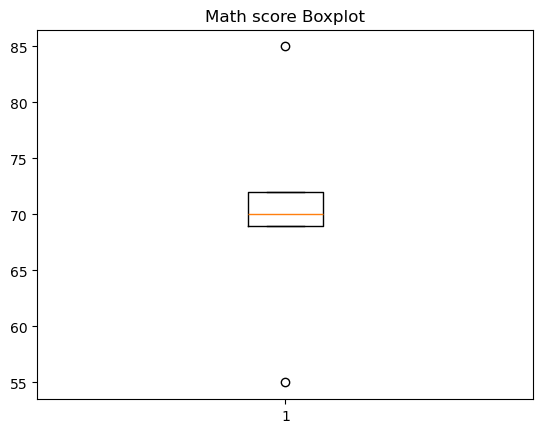

In [191]:
# Boxplot visualization

import matplotlib.pyplot as plt

plt.boxplot(df["Math_score"])
plt.title("Math score Boxplot")
plt.show()

In [193]:
df["Age"].dtype

dtype('float64')

In [195]:
print(type(df["Age"]))

<class 'pandas.core.series.Series'>


In [198]:
df["Age"].astype(int)
#this changes the data type but it hasn't changed it yet in the dataframe because we didn't assign it to the dataframe

0    17
1    17
2    16
3    20
4    17
Name: Age, dtype: int64

In [199]:
df = df["Age"].astype(int)

In [201]:
df.info()

<class 'pandas.core.series.Series'>
RangeIndex: 5 entries, 0 to 4
Series name: Age
Non-Null Count  Dtype
--------------  -----
5 non-null      int64
dtypes: int64(1)
memory usage: 172.0 bytes
